# Neural Networks Week 3 - Building an FNN with scikit-learn

This week we will use a much simpler way to build a Feed-Forward Neural Network (FNN) - using in-built functionality from scikit-learn. This package helps us with every stage of the process:
- Data set up (normalisation and splitting)
- Model Building
- Model Validation and Testing

The code in this tutorial is fairly simple, so this tutorial can be done very quickly, but I would urge you to try to strengthen two areas of knowledge: your ability to explore packages through documentation, and your understanding of the building blocks of Neural Networks. I would suggest you keep last session's tutorial open and try to recall what is going on under the surface of the package processes. Similarly as an extension to this tutorial, try to look through the documentation and see alternative approaches and setups.

First let's import our usual packages.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

If you do not have it already you will also need to install scikit-learn by uncommenting the cell below and running it.

In [2]:
# pip install scikit-learn

## 1 - Data Setup and Preparation
As with last session, the dataset we will be working with has two input features: 
- Spd: Wind Speed mean (m/s)
- Dir: Wind Direction (degrees)
  
and one output feature:
- Power: Produced Power (Watts)
  
We will build a very simple Neural Network aiming to predict Power from Dir and Spd. First we will import the data using pandas. This data set is quite large, for quick model training let's start by just looking at the first 10,000 rows.

In [3]:
# Read in data and print first 5 rows
data = pd.read_csv('Power_data.csv')[:10000]
data.head()

,Spd,Dir,Power
0,8.057867,140.604963,163091.471006
1,8.261681,194.859499,178473.313441
2,7.880412,267.160458,155353.906329
3,7.709666,244.524946,145472.892782
4,7.610075,139.184019,137384.522086


In [4]:
# Separate data into input and output and convert to array form
X = data[['Spd', 'Dir']].to_numpy()
y = data.Power.to_numpy()

We will now carry out our first operation using scikit-learn. You may notice that although the package and the install use the name `scikit-learn` we call imports using `sklearn`. This is because the dash in `scikit-learn` means it is not a valid callable package name, so we use a nickname instead. The first operation we are going to carry out is a `train_test_split`.

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
# Split data into 20% test data and 80% training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Explanation 1.1
Using last session's notebook (or your memory!) explain why it is important that we have split our data into training and test data.

## Exercise 1.1
Follow this link to view the docs for train_test_split: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

Use the documentation, as well as internet research if needed, to answer the following questions.
1. What does the test_size argument do?
2. What would be an equivalent way of writing this function without using the test_size argument?

## Answers 1.1

1. The test_size argument represents how much of the data should be used for the test set. If it is given as a float it should be a value between 0 and 1 representing the *proportion* of data that should be used as test data, if it is given as an integer it should represent the *number* of data points that should be used as test data.
2. This function could be written using train_size=0.8 which would equivalently split the data without using the test_size argument.

As with the previous session the next step we will carry out is normalisation, we can do this in a number of ways within scikit-learn - for this session we have chosen to use StandardScaler. There are a number advantages to this method, a key one being that we can undo normalisation later if needed.

In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
scaler_x = StandardScaler()
X_train_norm = scaler_x.fit_transform(X_train)
X_test_norm = scaler_x.transform(X_test)

## Explanation 1.2
Using last session's knowledge explain why it is important to carry out normalisation on our input data.

### Exercise 1.2
Use the docs to answer the following questions: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html 

1. What kind of scaling is carried out using this function?
2. What did we call this kind of scaling in last session's tutorial?
3. Extension exercise: go to https://scikit-learn.org/stable/api/sklearn.preprocessing.html and explore other normalisation methods. How could you carry out some of last session's other normalisation methods using this package?

### Answers 1.2

1. The data is scaled by removing the mean and scaling the variance. This sets mean to 0 and standard deviation to be 1.
2. Z-score normalisation

## 2 - Modelling
The scikit-learn package enables us to set up a feed-forward neural network model in just one line, reducing the workload a lot from semi-manual models like we created last session.
This package refers to feed-forward neural networks as Multi-layer Perceptrons (MLPs), which is a common alternative name for the model. In scikit-learn we have two types of MLP: MLPRegressor which handles continuous outputs and MLPClassifier which handles categorical (class) outputs.
For this problem we use an MLPRegressor, as out output is continuous.

In [9]:
from sklearn.neural_network import MLPRegressor

In [10]:
regr = MLPRegressor(random_state=42, max_iter=2000, tol=0.1)
regr.fit(X_train_norm, y_train)

C:\Users\kaiya.raby\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(max_iter=2000, random_state=42, tol=0.1)

It may look like there's a lot missing from a Neural Network model set-up. From this line alone we can't even really tell what our model looks like. Let's use the docs to figure it out.

### Exercise 2.1
1. What is the architecture of this model? (number and size of hidden layers)?
2. What argument and value would we use to have the same architecture as we used last session?
3. What activation function is being used?
4. What other activation functions are available?
5. What is the learning rate?

### Answers 2.1
1. One hidden layer with 100 neurons
2. hidden_layer_sizes = (8,) 
3. ReLu
4. tanh, identity and logistic
5. 0.001

## 3 - Testing
We can now use the model to predict the values for our test set using the `.predict()` method.

In [11]:
y_pred = regr.predict(X_test_norm)

scikit-learn also comes equipped with a metrics module with many useful measures of model success. We will use mean absolute percentage error (MAPE) but as an extension exercise it is well worth exploring this module to see all metrics available. Note: not all are suitable for testing regression problems as some are designed for classification settings, so focus on the Regression Metrics section.
https://scikit-learn.org/stable/api/sklearn.metrics.html

In [12]:
from sklearn.metrics import mean_absolute_percentage_error

In [13]:
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f'MAPE = {np.round(mape*100,2)}%')

MAPE = 0.87%


We can also use plotting to compare the true and predicted outputs.

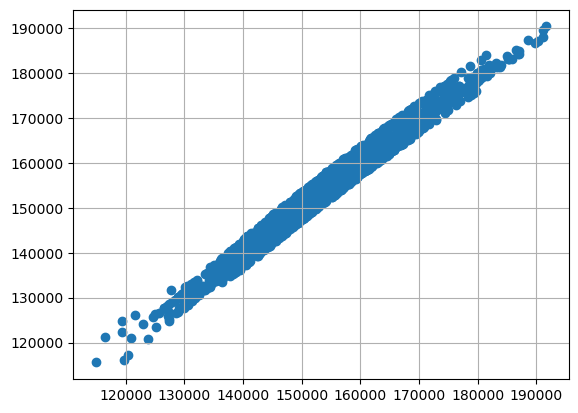

In [14]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.grid()

## 4 - Full Code
Let's have a look at the full code run-through start to finish. In just this (relatively) short chunk of code we have carried out a start to finish Neural Network modelling from data input to model testing. Packages like scikit-learn make Machine Learning methods incredibly simple and accessible. However, it is still important we don't lose sight of what is happening in the background as understanding these enables us to personalise these models to be appropriate for different problems.

In [15]:
# Read in data
data = pd.read_csv('Power_data.csv')[:10000]

# Split data into input and output
X = data[['Spd', 'Dir']].to_numpy()
y = data.Power.to_numpy()

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Normalise input data
scaler_x = StandardScaler()
X_train_norm = scaler_x.fit_transform(X_train)
X_test_norm = scaler_x.transform(X_test)

# Prepare and fit model
regr = MLPRegressor(random_state=42, max_iter=2000, tol=0.1)
regr.fit(X_train_norm, y_train)

# Predict and test model
y_pred = regr.predict(X_test_norm)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f'MAPE = {np.round(mape*100,2)}%')

MAPE = 0.87%


C:\Users\kaiya.raby\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


**Linear Activation Function**

The linear activation function is a simple straight line relationship characterised by
$$y = mx+c.$$
If an FNN uses only linear activation functions the final output results are always a linear combination of the input. The range of this function is $(-\infty, \infty)$, which limits it's usefulness in controlling the output range. The linear activation function is generally used to convert between final hidden layer and output layer. Linear activation functions are useful for some specific needs, but an FNN cannot soley rely on these functions as they would greatly limit the ability to learn complex pattern (it would ultimately be a linear regression model).

**Sigmoid Function**
  
The Sigmoid Activation Function is characterized by an 'S' shape. It is mathematically defined as $$A = \frac{1}{1+e^{-x}}.$$
Unlike the linear activation function, this method allows for a strictly controlled range between 0 and 1. 

**Tanh Activation Function**

Tanh function(hyperbolic tangent function) is a shifted version of the sigmoid, allowing it to stretch across the y-axis. It is defined as:$$A = tanh(x) = \frac{2}{1+e^{-2x}}-1 = 2 \text{ sigmoid}(2x)-1.$$

The range of this function is limited from -1 to 1. Since this method is non-linear it enables modeling of complex data patterns. It is commonly used within hidden layers due to its zero-centred output, making learning easier for later layers.

**ReLU (Rectified Linear Unit) Function**

The ReLU activation is defined by$$A(x) = max(0,x),$$
A(x)=max(0,x), this means that if the input x is positive, ReLU returns x, if the input is negative, it returns 0.$[0, \infty),$
meaning the function only outputs non-negative values.

**Leaky ReLU**
$$A = \begin{cases} 
x & \text{ if } x>0\\
x\alpha x & \text{ if } x \leq 0
\end{cases}$$

**Softmax Function**

Softmax function is designed to handle multi-class classification problems. It transforms raw output scores from a neural network into probabilities. It works by squashing the output values of each class into the range of 0 to 1 while ensuring that the sum of all probabilities equals 1.

Softmax is a non-linear activation function.
The Softmax function ensures that each class is assigned a probability, helping to identify which class the input belong

Impact of Activation Functions on Model Performance
The choice of activation function has a direct impact on the performance of a neural network in several ways:

Convergence Speed: Functions like ReLU allow faster training by avoiding the vanishing gradient problem while Sigmoid and Tanh can slow down convergence in deep networks.
Gradient Flow: Activation functions like ReLU ensure better gradient flow, helping deeper layers learn effectively. In contrast Sigmoid can lead to small gradients, hindering learning in deep layers.
Model Complexity: Activation functions like Softmax allow the model to handle complex multi-class problems, whereas simpler functions like ReLU or Leaky ReLU are used for basic layers. problems during optimization.s to.d in some cases for better gradient flow.and easy for computation., facilitating easier learning for subsequent layers.the training process. capabilities.

For this session we are using the ReLu function. This takes the maximum between 0 and the input. This means it sets any negative value to 0. Below we define the relu function and it's derivative (for back propagation).

In [16]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)